In [1]:
%pip install pyod

Note: you may need to restart the kernel to use updated packages.


In [11]:
from pyod.models.iforest import IForest
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

In [12]:
data = pd.read_csv(r'C:\Users\prana\Downloads\medicaid_provider_spending_MA_99214.csv')
data


,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID,claim_year,claim_month,claim_yyyymm
0,1275067118,1891903712,99214,2022-08,145,156,9608.76,2022,8,202208
1,1841514122,1255660684,99214,2022-12,119,140,9607.85,2022,12,202212
2,1013997329,1548592165,99214,2023-06,23,25,619.99,2023,6,202306
3,1629398219,1417242074,99214,2022-11,12,12,619.99,2022,11,202211
4,1538145131,1063706331,99214,2023-01,14,16,619.91,2023,1,202301
...,...,...,...,...,...,...,...,...,...,...
72420,1821349317,1528194958,99214,2022-06,13,13,620.74,2022,6,202206
72421,1215269626,1114215043,99214,2022-10,12,14,620.66,2022,10,202210
72422,1992073191,1558901991,99214,2023-12,16,17,89.57,2023,12,202312
72423,1992073191,1558901991,99214,2023-03,18,20,89.57,2023,3,202303


In [13]:
X = data.drop(columns=['BILLING_PROVIDER_NPI_NUM', 'SERVICING_PROVIDER_NPI_NUM', 'HCPCS_CODE', 'CLAIM_FROM_MONTH', 'TOTAL_UNIQUE_BENEFICIARIES', 'claim_year', 
                       'claim_month', 'claim_yyyymm'])
X_10000 = X[X['TOTAL_PAID'] >= 10000]

In [20]:
X_10000['TOTAL_PAID'].describe()

count      1323.000000
mean      34151.032766
std       48197.464409
min       10010.390000
25%       11874.810000
50%       15914.480000
75%       32592.030000
max      408631.250000
Name: TOTAL_PAID, dtype: float64

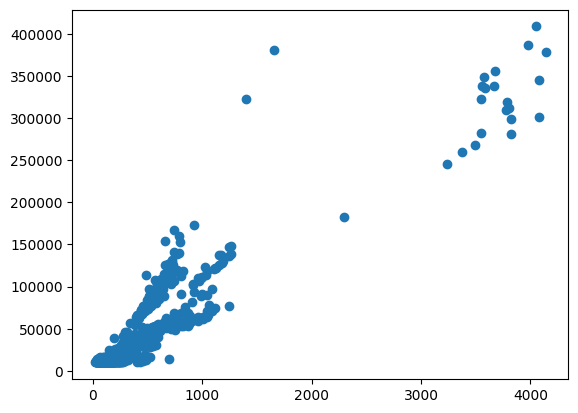

In [21]:
plt.scatter(X_10000.iloc[:, 0], X_10000.iloc[:, 1])
plt.show()


In [28]:
clf_name = 'IsolationForest'
clf = IForest(contamination=.01, random_state=42)
clf.fit(X_10000)


,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,1
,behaviour,'old'
,random_state,42
,verbose,0


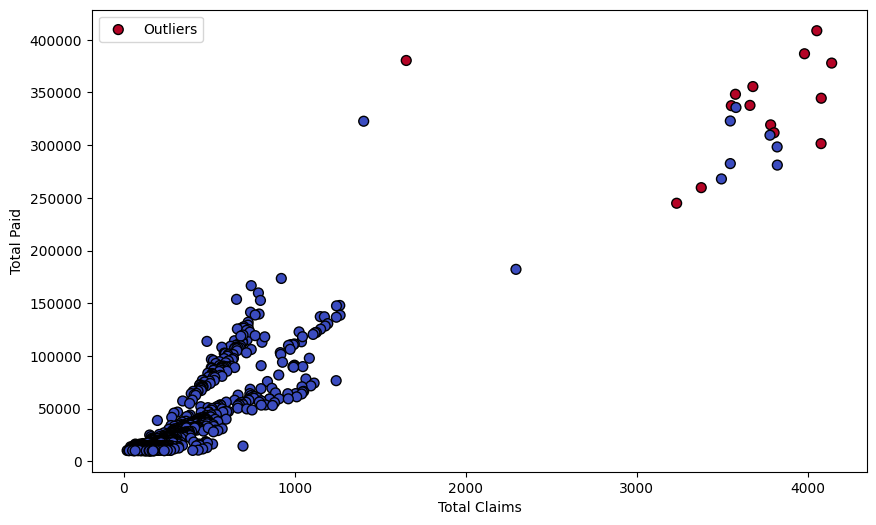

In [33]:
y_pred = clf.labels_
y_scores = clf.decision_scores_
outliers = X_10000[y_pred == 1]
plt.figure(figsize=(10, 6))
plt.scatter(X_10000.iloc[:, 0], X_10000.iloc[:, 1], c=y_pred, cmap='coolwarm',s=50, edgecolors='k')
plt.title(f'')
plt.xlabel('Total Claims')
plt.ylabel('Total Paid')
plt.legend(['Outliers', 'Inliers'])
plt.show()

In [40]:
print(np.sort(y_scores)[-10:])

[0.002864   0.0049767  0.00709513 0.00762563 0.0150905  0.01669933
 0.02154548 0.03242092 0.03681247 0.04344452]


In [38]:
X_results = X_10000.copy()
X_results['outlier_score'] = clf.decision_scores_
X_results['is_outlier'] = clf.labels_

top_t_outliers = X_results.nlargest(10, 'outlier_score')

print(top_t_outliers)

      TOTAL_CLAIMS  TOTAL_PAID  outlier_score  is_outlier
861           4054   408631.25       0.043445           1
944           4141   377924.41       0.036812           1
909           3982   386768.99       0.032421           1
1089          4080   344568.91       0.021545           1
1049          3680   355629.10       0.016699           1
1427          4079   301484.29       0.015090           1
943           1652   380388.64       0.007626           1
1088          3578   348321.94       0.007095           1
1130          3663   337769.36       0.004977           1
1322          3804   311801.95       0.002864           1


In [13]:
duplicate_count = data.duplicated().sum()
print(f"Total exact duplicate rows: {duplicate_count}")

Total exact duplicate rows: 0


In [16]:

features = ['TOTAL_CLAIMS','TOTAL_PAID']
feature_duplicates = data[data.duplicated(subset=features, keep=False)]
print(f"Rows with identical Features: {len(feature_duplicates)}")
print(feature_duplicates.groupby(features).size().reset_index(name='count').sort_values(by='count', ascending=False))


Rows with identical Features: 9136
      TOTAL_CLAIMS  TOTAL_PAID  count
538             14        0.00    186
243             13        0.00    182
799             15        0.00    166
0               12        0.00    153
1212            17        0.00    148
...            ...         ...    ...
2378            70     4216.10      2
606             14      506.94      2
605             14      505.26      2
601             14      494.11      2
2373            66     6569.51      2

[2421 rows x 3 columns]


In [3]:
import numpy as np
import pandas as pd

d = np.array([2,3,4,20]).reshape(-1,1)
print(d)

[[ 2]
 [ 3]
 [ 4]
 [20]]


In [ ]:
import numpy as np

class Node:
    def __init__(self, depth):
        self.depth = depth
        self.is_leaf = False
        self.split_value = None
        self. left = None
        self.right = None

def build_tree(X, current_depth = 0):
    node = Node(current_depth)

    if len(X) <= 1 or X.min() == X.max():
        node.is_leaf = True
        return node
    
    mn, mx = X.min(), X.max()
    node.split_value = np.random.uniform(mn,mx)

    left_data = X[X <= node.split_value]
    right_data = X[X > node.split_value]

    node.left = build_tree(left_data, current_depth+1)
    node.right = build_tree(right_data, current_depth+1)

    return node

def get_path_length(point, node):
    if node.is_leaf:
        return node.depth

    if point <= node.split_value:
        return get_path_length(point, node.right)
    else:
        return get_path_length(point, node.right) 
    
my_data = np.array([10,11,12,13,15,21,100]).reshape(-1,1)

my_tree = build_tree(my_data)

for point in my_data.flatten():
    depth = get_path_length(point, my_tree)
    print(f'Data point {point:3} -> Path length: {depth}')

Data point  10 -> Path length: 1
Data point  11 -> Path length: 1
Data point  12 -> Path length: 1
Data point  13 -> Path length: 1
Data point  15 -> Path length: 1
Data point  21 -> Path length: 1
Data point 100 -> Path length: 1


In [ ]:
top_10                                                                                                       